In [1]:
# Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster. (Part 3, 4:19 - 40:40)

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('turkce_isimler.txt', 'r').read().splitlines()
words[:8]

['Ada',
 'Adaadem',
 'Adaahmet',
 'Adaali',
 'Adaalp',
 'Adaalparslan',
 'Adaalper',
 'Adaarda']

In [4]:
len(words)

103637

In [5]:
def lowercase(s):
    s = s.replace('İ', 'i').replace('I', 'ı')
    return s.lower()

words_cleaned = [lowercase(n) for n in words]
print(words_cleaned[:10])
words = words_cleaned.copy()

['ada', 'adaadem', 'adaahmet', 'adaali', 'adaalp', 'adaalparslan', 'adaalper', 'adaarda', 'adaasel', 'adaaslan']


In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'ç', 25: 'ö', 26: 'ü', 27: 'ğ', 28: 'ı', 29: 'ş', 0: '.'}
30


In [7]:
block_size = 3  # context length: how many characters do we take to predict the next one?

def building_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = building_dataset(words[:n1])     # 80%
Xdev, Ydev = building_dataset(words[n1:n2])   # 10%
Xte,  Yte  = building_dataset(words[n2:])     # 10%

torch.Size([891788, 3]) torch.Size([891788])
torch.Size([111351, 3]) torch.Size([111351])
torch.Size([111819, 3]) torch.Size([111819])


In [8]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(42) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12730


In [9]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.4020
  10000/ 200000: 1.5236
  20000/ 200000: 1.3397
  30000/ 200000: 1.5548
  40000/ 200000: 1.7864
  50000/ 200000: 1.7137
  60000/ 200000: 1.7819
  70000/ 200000: 1.6062
  80000/ 200000: 2.4242
  90000/ 200000: 1.5916
 100000/ 200000: 1.2791
 110000/ 200000: 1.4542
 120000/ 200000: 1.2471
 130000/ 200000: 1.4972
 140000/ 200000: 1.3869
 150000/ 200000: 1.5086
 160000/ 200000: 1.8928
 170000/ 200000: 1.0532
 180000/ 200000: 1.2556
 190000/ 200000: 1.3891


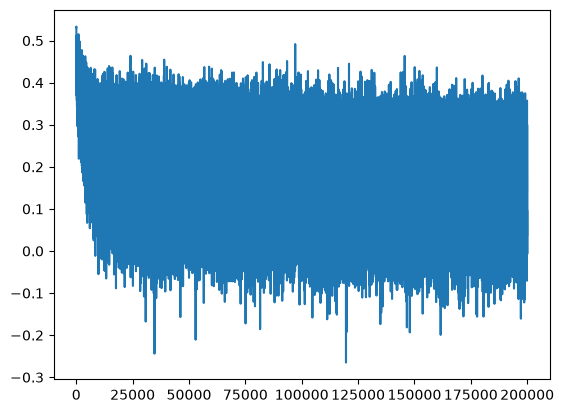

In [9]:
plt.plot(lossi)

In [10]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [11]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.4533244371414185
val 1.4667826890945435


## Görev 5

In [64]:
# eğer model tamamen rastgele tahmin yapsaydı, her karakter eşit olasılıkla gelirdi
# beklenen başlangıç loss'u:
-torch.tensor(1/30).log()

tensor(3.4012)

In [65]:
# parametreleri rastgele başlatıp  ilk adımdaki lossu öğrenelim
g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

26.633846282958984


In [66]:
#loss neden bu kadar yüksek logitlere bakalım logits = h @ W2 + b2
logits[0]

tensor([-17.0891,  -8.5803,  -2.8913,  27.1685,  14.6165,  -0.3338,   8.0681,
         -3.2140,   2.9476,  -5.7044,  -0.0473, -21.4818,  -0.6167,  34.2705,
        -10.2529,  16.1434,   2.2102, -32.0760,   4.5676,   5.4224,   2.0465,
        -13.6865, -10.4355,  13.3743,   5.0836,  -3.2936,   2.0214,  -9.4936,
          5.1643,  -3.2319], grad_fn=<SelectBackward0>)

In [67]:
# -21 +27 gibi çok büyük ve küçük değereler aldığını görüyoruz bu değerler lossu artırıyor.

In [68]:
# nasıl çözeriz? çıkış katmanını küçültmemiz gerek 
# Mantık: eğitimin başında model kararsız olmalı yani tüm karakterlere yakın olasılık vermeli logit'ler birbirine yakın olmalı 0 gibi

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
h = torch.tanh(emb.view(-1, block_size*n_embd) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

3.3955984115600586


In [69]:
# neden W2 ye 0.01 verdik ? 
# amaç: eğitim başlamadan önce model hiçbir karaktere aşırı güven duymasın yani tüm karakterler için ürettiği logitler birbirine yakın olsun 
# ideal olarak hepsi 0 civarı olmalı  böylece softmax sonrası olasılıklar neredeyse her karaktere eşit olasılıkta çıksın.
# logits = h @ W2 + b2 formülüne baktığımıda h değerleri zaten tanh çıktısı olduğu için -1 ile 1 aralığında sınırlıdır. Ama W2 çok büyük olursa h @ W2 olduğu için 
# toplam olduğu için rastgele büyük pozitif veya negatif değerlerin toplanması sonucu çok büyük sayılara ulaşabilir.
# W2'yi 0.01 ile çarpmak bu çarpımı küçük tutuyor logitler 0 a yakın kalıyor dolayısıyla softmax çıktısı yaklaşık değerler oluyor 
# loss da beklenen log(vocab_size) değerine yakın çıkıyor.

# W2 neden 0 değil öğrenme akışını tamamen durmasın diye çünkü 0 olsaydı giriş değerinin çıkış değerine bir etkisi olmayacaktı.
# neden b2 yi 0 yaptık ? 
# çünkü b2 * 0 her karaktere sistematik keyfi bir önyargı eklenmesini engelliyor. b2 zaten h dan  gelen bilgiyi taşımıyor sadece sabit bir kaydırma olduğu için sıfır yapmak gradyan akışını engellemiyor.

Text(0, 0.5, 'örnek 500 rastgele satır')

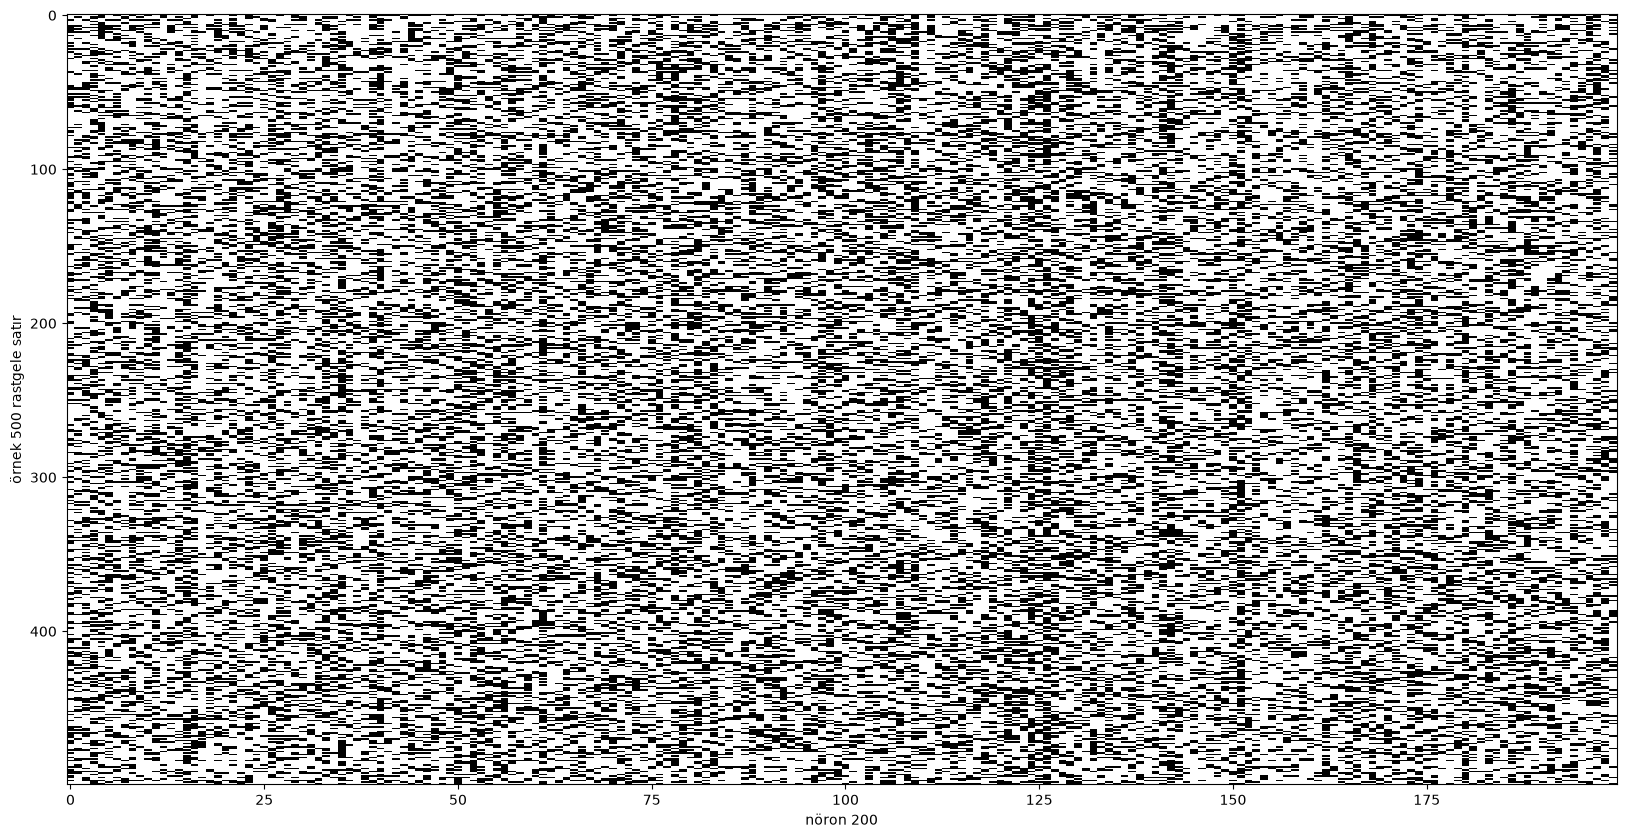

In [70]:
sample_idx = torch.randint(0, h.shape[0], (500,)) 
h_sample = h[sample_idx].abs().detach().numpy() > 0.99

plt.figure(figsize=(20,10))
plt.imshow(h_sample, cmap='gray', interpolation='nearest', aspect='auto')
plt.xlabel('nöron 200')
plt.ylabel('örnek 500 rastgele satır')

(array([64908595.,  4058449.,  2466321.,  1943751.,  1398883.,  1338667.,
         1021255.,   976444.,   772996.,   720598.,   721694.,   754681.,
          673161.,   581165.,   627104.,   534485.,   488367.,   505899.,
          562809.,   563419.,   642778.,   457890.,   469442.,   447628.,
          449825.,   477970.,   528293.,   703739.,   456086.,   519399.,
          485639.,   497750.,   490086.,   531113.,   607144.,   673706.,
          598580.,   788609.,   675751.,   794379.,   750416.,   816357.,
          870195.,  1052927.,  1091816.,  1549834.,  1971523.,  2316872.,
         4594365., 66428745.]),
 array([-1.        , -0.95999998, -0.92000002, -0.88      , -0.84000003,
        -0.80000001, -0.75999999, -0.72000003, -0.68000001, -0.63999999,
        -0.60000002, -0.56      , -0.51999998, -0.48000002, -0.44      ,
        -0.40000004, -0.36000001, -0.31999999, -0.28000003, -0.24000001,
        -0.20000005, -0.16000003, -0.12      , -0.08000004, -0.04000002,
         0.

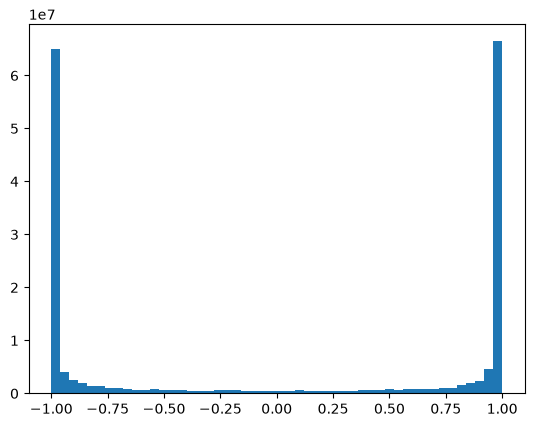

In [71]:
plt.hist(h.view(-1).detach().numpy(), 50)

In [72]:
# Bu, Kaiming initten önceki düzeltilmemiş modelin çıktısıdır. 
# tanh'a giren ham değerler çok geniş bir aralıkta dağıldığı için -15, +20 gibi tanh fonksiyonu bu kadar büyük girdilerde zaten neredeyse tamamen -1 veya +1'e yapışıyor yani matematiksel olarak tanh(15) ≈ 0.9999999..
# tanh'ın türevi: d(tanh(x))/dx = 1 - tanh(x)^2. Eğer tanh(x) ≈ ±1 ise bu türev ≈ 1 - 1 = 0a çok yakın oluyor. 
# Yani bu nöronlardan gradyan neredeyse hiç geçmiyor backward pass sırasında bu nöronlar öğrenmeyi durdurmuş gibi davranıyor. 
# Grafikte neredeyse tüm değerlerin ±1 de olması ağın büyük kısmının şu an öğrenemez durumda olduğu anlamına geliyor.

In [73]:
print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

Doygun (|h|>0.99) oranı: 64.88%


In [75]:
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
hpreact = emb.view(-1, block_size*n_embd) @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

3.411393404006958
Doygun (|h|>0.99) oranı: 2.74%


Text(0, 0.5, 'örnek 500 rastgele satır')

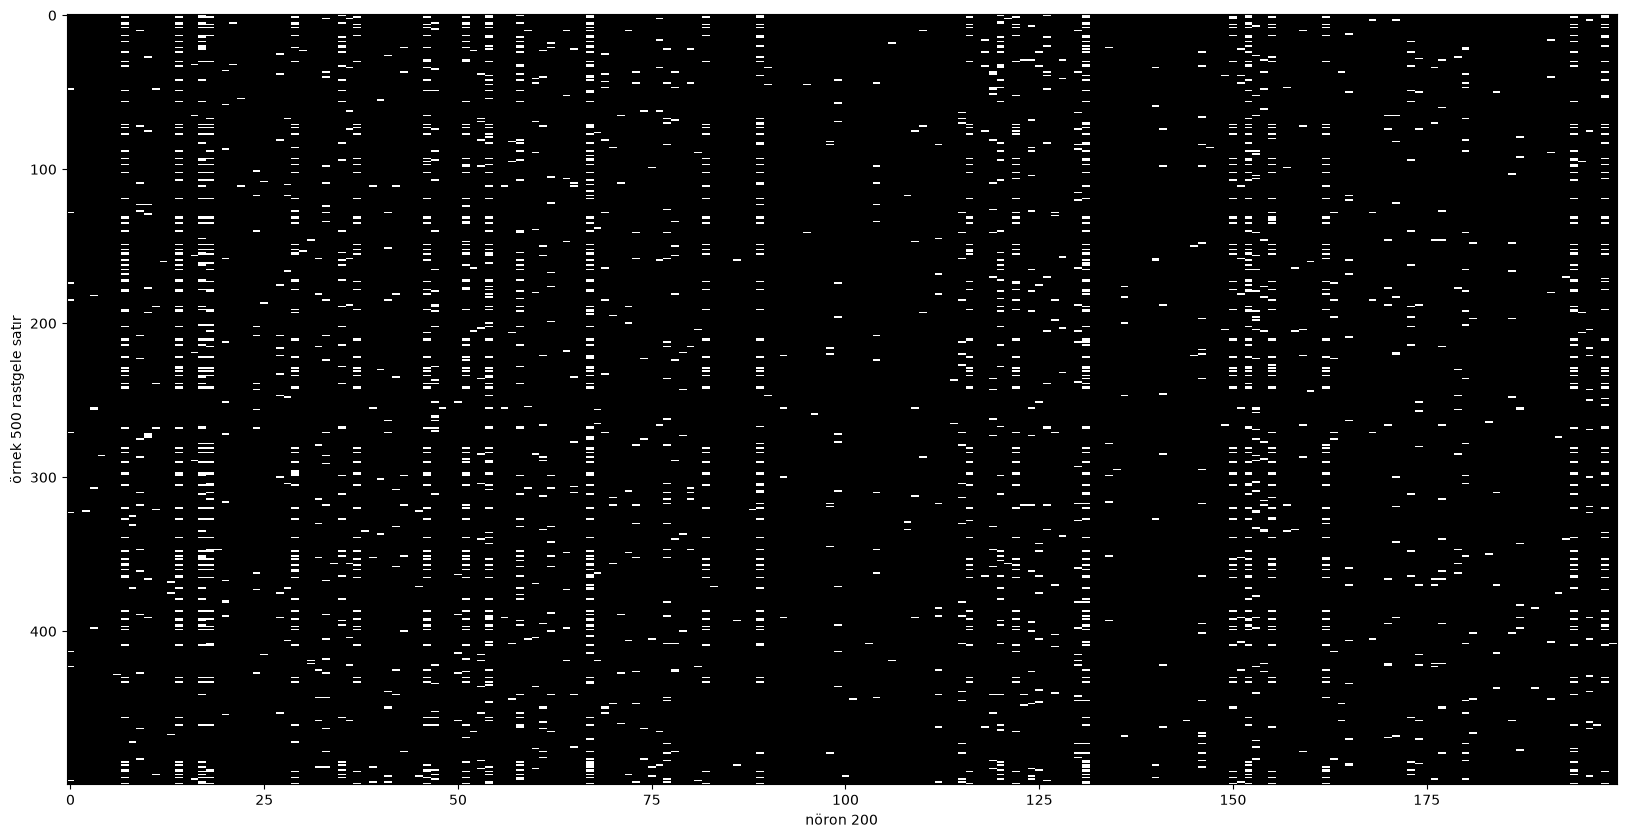

In [76]:
sample_idx = torch.randint(0, h.shape[0], (500,)) 
h_sample = h[sample_idx].abs().detach().numpy() > 0.99

plt.figure(figsize=(20,10))
plt.imshow(h_sample, cmap='gray', interpolation='nearest', aspect='auto')
plt.xlabel('nöron 200')
plt.ylabel('örnek 500 rastgele satır')

In [77]:
# "W2/b2 yi küçültmek başlangıç loss'unu düzeltti
#  W1/b1'i küçültmek ise tanh'ın doygunluğunu önleyip nöronların öğrenmeye devam edebilmesini sağladı

In [78]:
# kaiming init formülünü hesaplama   
fan_in = block_size * n_embd
gain = 5/3   # tanh için Kaimingin önerdiği sabit
std = gain / (fan_in**0.5)
print(std)

0.3042903097250923


In [79]:
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3) / ((block_size*n_embd)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

emb = C[Xtr]
hpreact = emb.view(-1, block_size*n_embd) @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

print('Doygun (|h|>0.99) oranı: %.2f%%' % (100 * (h.abs() > 0.99).float().mean().item()))

3.410125732421875
Doygun (|h|>0.99) oranı: 13.06%


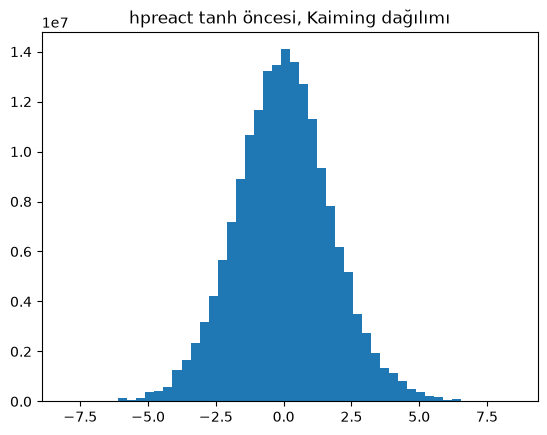

In [80]:
plt.hist(hpreact.view(-1).detach().numpy(), 50)
plt.title('hpreact tanh öncesi, Kaiming dağılımı')
plt.show()

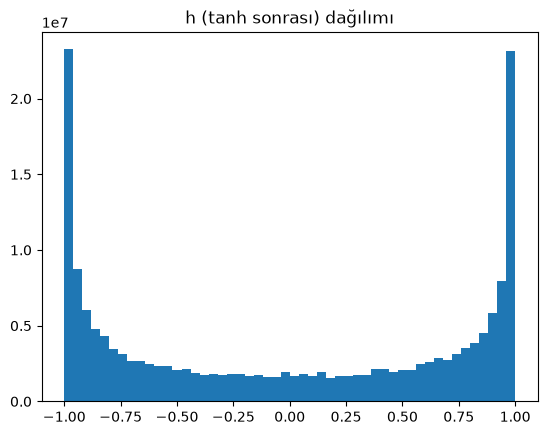

In [81]:
plt.hist(h.view(-1).detach().numpy(), 50)
plt.title('h (tanh sonrası) dağılımı')
plt.show()

## Görev 6 ve Görev 7

In [ ]:
# BatchNorm katmanını gizli katmandan sonra ekle. Eğitim sırasında batch istatistiği, tahmin sırasında running mean kullan. BatchNorm'lu ve BatchNorm'suz modelin dev loss'unu karşılaştır. (40:40 - 1:04:50)

In [13]:
# Geçen haftaki Türkçe isim listenle aynı modeli eğit. Türkçe'de ürettiği isimlerden örnekler ve dev loss'u göster. Bigram'ın Türkçe sonuçlarıyla yan yana koy.

In [ ]:
n_embd = 10 
n_hidden = 200 

def init_params(seed=42):
    g = torch.Generator().manual_seed(seed)
    C  = torch.randn((vocab_size, n_embd), generator=g)
    W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
    b1 = torch.randn(n_hidden, generator=g) * 0.01
    W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
    b2 = torch.randn(vocab_size, generator=g) * 0
    return C, W1, b1, W2, b2, g

# ---- BatchNorm'suz model ----
C, W1, b1, W2, b2, g = init_params()
parameters_nobn = [C, W1, b1, W2, b2]
for p in parameters_nobn:
    p.requires_grad = True

max_steps = 200000
batch_size = 32

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1       # BatchNorm yok, bias direkt burada
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters_nobn:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters_nobn:
        p.data += -lr * p.grad

    if i % 20000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

@torch.no_grad()
def dev_loss_nobn():
    emb = C[Xdev]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Ydev).item()

loss_nobn = dev_loss_nobn()
print('BatchNorm suz dev loss:', loss_nobn)

      0/ 200000: 3.4098
  20000/ 200000: 1.3756
  40000/ 200000: 1.7789
  60000/ 200000: 1.6310
  80000/ 200000: 2.2388
 100000/ 200000: 1.3602
 120000/ 200000: 1.1816
 140000/ 200000: 1.3914
 160000/ 200000: 1.8426
 180000/ 200000: 1.2568
BatchNorm SUZ dev loss: 1.4469051361083984


In [ ]:
# ---- BatchNorm'lu model ----
C, W1, b1, W2, b2, g = init_params()

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

parameters_bn = [C, W1, W2, b2, bngain, bnbias]   
for p in parameters_bn:
    p.requires_grad = True

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)
    
    # Linear layer

    hpreact = embcat @ W1   # b1 eklemiyoruz, BatchNorm zaten kendi bias'ını (bnbias) ekliyor 

    # ---- BatchNorm katmanı ----
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi  = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
    # ---------------------------
    # Non-linearity
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters_bn:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters_bn:
        p.data += -lr * p.grad

    if i % 20000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

@torch.no_grad()
def dev_loss_bn():
    emb = C[Xdev]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Ydev).item()

loss_bn = dev_loss_bn()
print('BatchNorm lu dev loss:', loss_bn)

      0/ 200000: 3.4020
  20000/ 200000: 1.3397
  40000/ 200000: 1.7864
  60000/ 200000: 1.7819
  80000/ 200000: 2.4242
 100000/ 200000: 1.2791
 120000/ 200000: 1.2471
 140000/ 200000: 1.3869
 160000/ 200000: 1.8928
 180000/ 200000: 1.2556
BatchNorm LU dev loss: 1.4667826890945435


In [12]:

print(f'BatchNorm suz dev loss : {loss_nobn:.4f}')
print(f'BatchNorm lu  dev loss : {loss_bn:.4f}')

BatchNorm suz dev loss : 1.4469
BatchNorm lu  dev loss : 1.4668


In [ ]:
# BatchNorm, özellikle derin ağlarda katman katman aktivasyon dağılımını otomatik dengeleyerek init'e olan bağımlılığı azaltır.
# Ama bizim ağımız tek katmanlı ve zaten Kaiming init ile iyi bir başlangıç noktasına sahip olduğu için, BatchNorm eklemek bu deneyde ölçülebilir bir iyileşme sağlamadı
# hatta batch istatistiğinin getirdiği küçük gürültü yüzünden marjinal olarak daha yüksek dev loss'a yol açtı. 
# Bu, BatchNorm'un 'her zaman iyileştirir' değil, 'derin ağlarda init'i garantiye alır' bir araç olduğunu gösteriyor.

In [14]:
g_sample = torch.Generator().manual_seed(22)
generated_names = []
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    name = ''.join(itos[i] for i in out)
    print(name)
    generated_names.append(name)

fikretışık.
azrasim.
ser.
irfan.
ayşe.
orhanhümeyrazçağlavaşzerr.
nilil.
yusuferihatuhan.
selingün.
doğa.
vdoğa.
kaya.
han.
esmailgınilüferberk.
nazerrihati.
poyra.
jalezar.
ayzörkem.
pamuk.
ike.


In [16]:
print('Bigram modeli')
print('Sayım modeli loss :', 2.4546)
print('Sinir ağı loss    :', 2.4440)
print('Örnek isimler     : bak., slmik., an., kay., hay., tanış.\n')

print('MLP + BatchNorm modeli')
print('Dev loss          :', f'{loss_bn:.4f}')
print('Örnek isimler     :', ', '.join(generated_names[:6]), '\n')

Bigram modeli
Sayım modeli loss : 2.4546
Sinir ağı loss    : 2.444
Örnek isimler     : bak., slmik., an., kay., hay., tanış.

MLP + BatchNorm modeli
Dev loss          : 1.4668
Örnek isimler     : fikretışık., azrasim., ser., irfan., ayşe., orhanhümeyrazçağlavaşzerr. 



## Görev 8

In [ ]:
#Ek, erken bitirenler için, Karpathy'nin video altındaki egzersizlerinden birini seç: Bütün weight ve bias'ları sıfırla başlat, ağı eğit, neyin kısmen öğrendiğini gradient ve aktivasyonlardan bul (Part 3, E01). Ya da BatchNorm'u eğitimden sonra bir önceki Linear katmanın W ve b'sine katla, forward pass'in aynı kaldığını göster (Part 3, E02). Ya da hiperparametreleri ayarlayıp Karpathy'nin 2.2 validation loss'unu geç

In [29]:
# ---- Görev 8 (E01): tüm ağırlık ve bias'ları SIFIR ile başlat ----
g = torch.Generator().manual_seed(42)

C0  = torch.zeros((vocab_size, n_embd))
W10 = torch.zeros((n_embd * block_size, n_hidden))
b10 = torch.zeros(n_hidden)
W20 = torch.zeros((n_hidden, vocab_size))
b20 = torch.zeros(vocab_size)

parameters_zero = [C0, W10, b10, W20, b20]
names_zero = ['C', 'W1', 'b1', 'W2', 'b2']
for p in parameters_zero:
    p.requires_grad = True

max_steps = 30000
batch_size = 32
lossi_zero = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C0[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W10 + b10
    h = torch.tanh(hpreact)
    logits = h @ W20 + b20
    loss = F.cross_entropy(logits, Yb)

    for p in parameters_zero:
        p.grad = None
    loss.backward()

    if i == 0:
        print('=== İlk adımdaki gradyan büyüklükleri (|grad|.mean()) ===')
        for name, p in zip(names_zero, parameters_zero):
            print(f'{name:4s}: grad mean(abs) = {p.grad.abs().mean().item():.8f}')
        print()

    lr = 0.1
    for p in parameters_zero:
        p.data += -lr * p.grad

    if i % 5000 == 0:
        print(f'{i:6d}/{max_steps}: loss = {loss.item():.4f}')
    lossi_zero.append(loss.item())

print('\nSon loss:', lossi_zero[-1])

=== İlk adımdaki gradyan büyüklükleri (|grad|.mean()) ===
C   : grad mean(abs) = 0.00000000
W1  : grad mean(abs) = 0.00000000
b1  : grad mean(abs) = 0.00000000
W2  : grad mean(abs) = 0.00000000
b2  : grad mean(abs) = 0.03416667

     0/30000: loss = 3.4012
  5000/30000: loss = 2.9272
 10000/30000: loss = 3.1328
 15000/30000: loss = 3.0090
 20000/30000: loss = 3.1228
 25000/30000: loss = 3.2311

Son loss: 2.990757942199707


In [32]:
print('=== Eğitim sonrası parametrelerin durumu ===')
for name, p in zip(names_zero, parameters_zero):
    hala_sifir = torch.all(p == 0).item()
    print(f'{name:4s} abs().max() = {p.abs().max().item():.6f}')

=== Eğitim sonrası parametrelerin durumu ===
C    abs().max() = 0.000000
W1   abs().max() = 0.000000
b1   abs().max() = 0.000000
W2   abs().max() = 0.000000
b2   abs().max() = 2.310365


In [ ]:
ratio = torch.bincount(Ytr, minlength=vocab_size).float()
ratio_probs = ratio / ratio.sum()
b2_probs = F.softmax(b20, dim=0)

print(f'{"karakter":10s} {"gerçek frekans":>15s} {"b2 softmax":>12s}')
for i in range(vocab_size):
    print(f'{itos[i]:10s} {ratio_probs[i].item():15.4f} {b2_probs[i].item():12.4f}')

unigram_entropy = -(ratio_probs * (ratio_probs + 1e-9).log()).sum()
print('\nTeorik unigram entropi:', unigram_entropy.item())
print('Sıfır-init modelin ulaştığı son loss  :', lossi_zero[-1])

karakter    gerçek frekans   b2 softmax
.                   0.0930       0.0970
a                   0.1339       0.1379
b                   0.0171       0.0155
c                   0.0137       0.0138
d                   0.0248       0.0259
e                   0.0975       0.0942
f                   0.0138       0.0130
g                   0.0154       0.0148
h                   0.0237       0.0239
i                   0.0558       0.0589
j                   0.0022       0.0022
k                   0.0366       0.0366
l                   0.0525       0.0503
m                   0.0368       0.0354
n                   0.0690       0.0692
o                   0.0137       0.0143
p                   0.0105       0.0106
r                   0.0642       0.0652
s                   0.0283       0.0289
t                   0.0340       0.0333
u                   0.0385       0.0360
v                   0.0123       0.0118
y                   0.0306       0.0311
z                   0.0236       0.0228


In [33]:
@torch.no_grad()
def split_loss_zero(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C0[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W10 + b10)
  logits = h @ W20 + b20
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss_zero('train')
split_loss_zero('val')

train 3.0449910163879395
val 3.042489528656006


In [ ]:
# Sıfır init ile ağ tamamen ölü kalmıyor ama neredeyse hiçbir şey de öğrenmiyor 
# simetri hiç bozulmadığı için sadece çıkış katmanının bias'ı yani b2 gradyan alabiliyor, o da context'i görmeden sadece karakterlerin genel frekansını
# ezberliyor. Bütün ağırlık matrisleri (C, W1, W2) ve gizli katmanın bias'ı b1 matematiksel olarak sonsuza kadar tam sıfırda kilitli kalıyor. Bu, rastgele init'in 
# neden zorunlu olduğunu gösteren klasik bir symmetry breaking problemi.

#https://colab.research.google.com/drive/1H5CSy-OnisagUgDUXhHwo1ng2pjKHYSN?usp=sharing#scrollTo=2qDFBVoBsXck videodaki collab